# Real Estate - Feature Analysis

##

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

from src.features.build_features import rename_features, prepare_rf_features

BASE_DIR = Path().resolve().parents[0]
file_path = BASE_DIR / "data/processed/dvf_processed.parquet"

df = pd.read_parquet(file_path)

In [2]:
print(df.shape)
df.head()

(379890, 38)


,Date mutation,Nature mutation,Valeur fonciere,No voie,Type de voie,Code voie,Voie,Code postal,Commune,Code departement,...,Nombre d'établissements 2024,Effectifs salariés 2024,"École maternelle, primaire, élémentaire (en nombre) 2024",Collège (en nombre) 2024,Lycée (en nombre) 2024,Pharmacie (en nombre) 2024,Médecin généraliste (en nombre) 2024,Taux de chômage trimestriel 2025-T4,Salaire net EQTP mensuel moyen 2023,Taux de pauvreté 2023
0,2025-01-09,Vente,183000.0,250.0,AV,0041,DE BELLE FERME,1170,GEX,01,...,209,2423,6,2,0,3,5,6.4,2364,15.4
1,2025-01-08,Vente,131937.3,62.0,CHE,0950,DU PEUPLE,1330,AMBERIEUX-EN-DOMBES,01,...,49,195,1,0,0,1,1,5.8,2587,6.7
2,2025-01-09,Vente,173000.0,5338.0,,B006,GRAND FAUBOURG,1290,PONT-DE-VEYLE,01,...,51,561,1,1,1,1,4,6.1,2366,7.8
3,2025-01-06,Vente,414665.0,124.0,CHE,0032,DE CHAMP JOURNET,1630,CHALLEX,01,...,11,112,1,0,0,0,0,6.4,2364,15.4
4,2025-01-10,Vente,259000.0,85.0,RUE,0101,DE CHATEAU GAGNEUR,1170,GEX,01,...,209,2423,6,2,0,3,5,6.4,2364,15.4


### Quick checks

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 379890 entries, 0 to 379889
Data columns (total 38 columns):
 #   Column                                                                          Non-Null Count   Dtype         
---  ------                                                                          --------------   -----         
 0   Date mutation                                                                   379890 non-null  datetime64[us]
 1   Nature mutation                                                                 379890 non-null  category      
 2   Valeur fonciere                                                                 379890 non-null  float64       
 3   No voie                                                                         376721 non-null  float64       
 4   Type de voie                                                                    379890 non-null  string        
 5   Code voie                                                                   

In [4]:
df.describe()

,Date mutation,Valeur fonciere,No voie,Code commune,No plan,Code type local,Surface reelle bati,Nombre pieces principales,prix_m2,longitude,...,Nombre d'établissements 2024,Effectifs salariés 2024,"École maternelle, primaire, élémentaire (en nombre) 2024",Collège (en nombre) 2024,Lycée (en nombre) 2024,Pharmacie (en nombre) 2024,Médecin généraliste (en nombre) 2024,Taux de chômage trimestriel 2025-T4,Salaire net EQTP mensuel moyen 2023,Taux de pauvreté 2023
count,379890,3.798900e+05,376721.000000,379890.000000,379890.000000,379890.000000,379890.000000,379890.000000,379890.000000,379890.000000,...,336560.0,336560.0,336560.0,336560.0,336560.0,336560.0,336560.0,336560.0,336540.0,336063.0
mean,2025-07-06 22:06:09.694385,2.275008e+05,446.250501,185.826247,332.787494,2.085388,60.477907,2.450623,3955.016964,2.960181,...,3067.82273,43922.186671,38.017233,7.926206,7.907981,25.735893,87.470264,7.664995,2671.416658,16.672213
min,2025-01-02 00:00:00,2.000000e+03,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1357.142857,-63.077393,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.9,1889.0,4.0
25%,2025-04-09 00:00:00,1.200000e+05,8.000000,61.000000,69.000000,2.000000,37.000000,2.000000,2433.333333,1.502286,...,403.0,3624.0,6.0,1.0,0.0,3.0,10.0,6.7,2343.0,14.0
50%,2025-07-07 00:00:00,1.760000e+05,24.000000,130.000000,178.000000,2.000000,55.000000,2.000000,3442.622951,2.566732,...,1239.0,14011.0,18.0,4.0,3.0,11.0,30.0,7.5,2526.0,17.2
75%,2025-10-01 00:00:00,2.672678e+05,76.000000,264.000000,384.000000,2.000000,73.000000,3.000000,4941.176471,5.374045,...,3974.0,61338.0,46.0,11.0,12.0,33.0,102.0,8.2,2713.0,19.6
max,2025-12-31 00:00:00,6.900000e+07,9999.000000,907.000000,7910.000000,4.000000,21073.000000,89.000000,10250.000000,55.800980,...,19612.0,349860.0,226.0,43.0,47.0,157.0,549.0,14.4,3744.0,33.5
std,NaN,3.239669e+05,1673.800873,163.476030,547.437713,0.569834,78.613610,1.324795,2016.962040,6.978742,...,4391.023664,68178.269007,49.707599,9.982279,11.137471,36.78803,133.816381,1.603232,479.671971,4.28441


### Numerical features

In [5]:
df = rename_features(df)

features = [
    "Valeur fonciere",
    "Surface reelle bati",
    "Nombre pieces principales",
    "prix_m2",
    "longitude",
    "latitude",
    "MED_SL",
    "LOG",
    "NB_EMPLT",
    "EVOL_POP",
    "EVOL_POP_E_S",
    "LEGAL_UNIT",
    "LEGAL_UNIT_NEW",
    "UNIT_LOC",
    "NB_EMPL",
    "ECOLE",
    "COLLEGE",
    "LYCEE",
    "PHARMACIE",
    "MEDECIN",
    "CHOMAGE",
    "SL",
    "PR_MD60"
]

city_features = features + ["Code postal"]

features_RF = [
    # REMINDER : prix_m2 = Valeur fonciere / Surface reelle bati
    # therefor : prix_m2, Valeur fonciere and Surface relle bati are excluded
    "Nombre pieces principales",
    "longitude",
    "latitude",
    "MED_SL",
    "LOG",
    "NB_EMPLT",
    "EVOL_POP",
    "EVOL_POP_E_S",
    "LEGAL_UNIT",
    "LEGAL_UNIT_NEW",
    "UNIT_LOC",
    "NB_EMPL",
    "ECOLE",
    "COLLEGE",
    "LYCEE",
    "PHARMACIE",
    "MEDECIN",
    "CHOMAGE",
    "SL",
    "PR_MD60"
]

analysis_features = df[features]

city_analysis_features = df[city_features]

## Correlation matrix

In [37]:
corr = analysis_features.corr(numeric_only=True)

## Heatmap (Correlation)

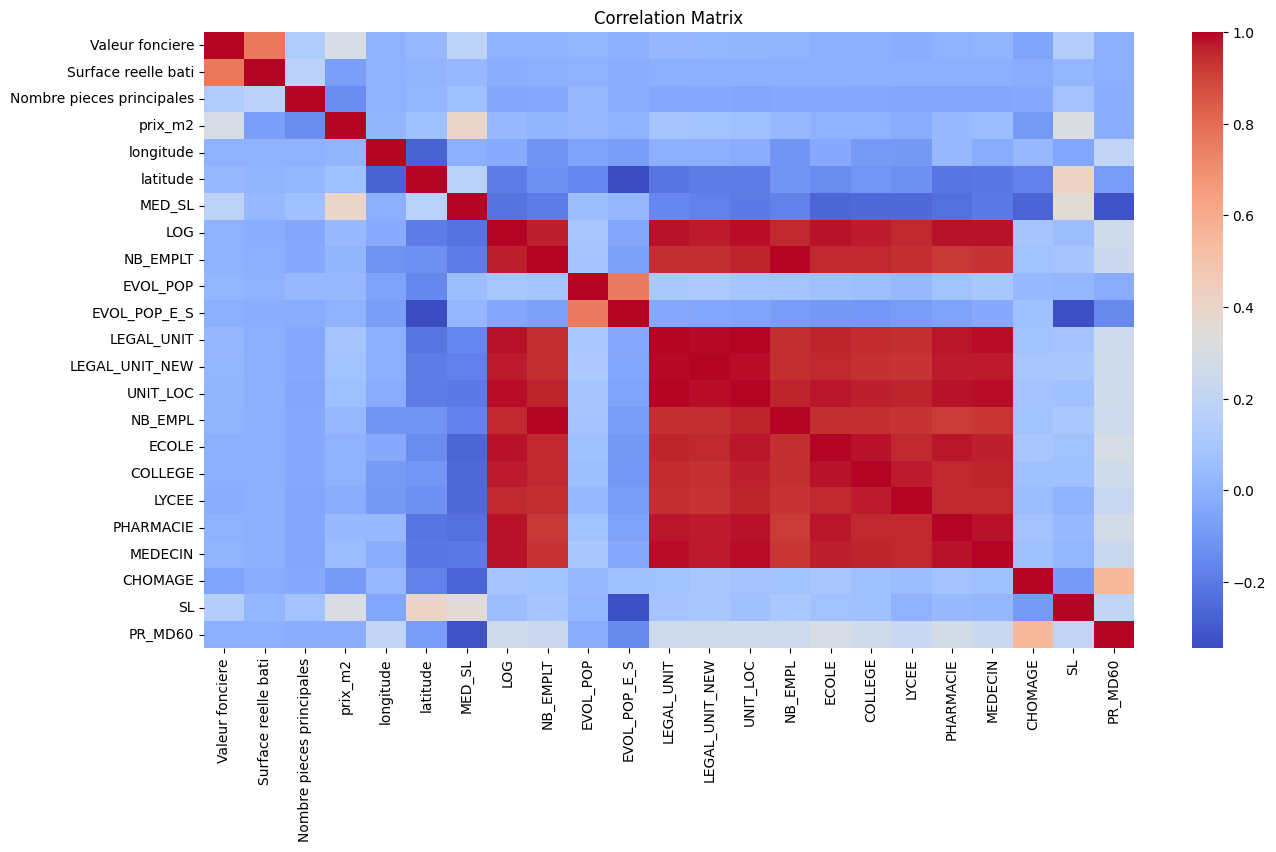

In [7]:
plt.figure(figsize=(15, 8))

sns.heatmap(
    corr,
    annot=False,
    fmt=".2f",
    cmap="coolwarm",
)

plt.title("Correlation Matrix")
plt.show()

- Strong positive correlations between socio-economic variables (SL, MED_SL, NB_EMPLT)
   - Wealthy areas tend to score high on all indicators simultaneously
- LOG, UNIT_LOC, NB_EMPL are strongly correlated : measure urban density
- EVOL_POP and EVOL_POP_E_S are correlated (migratory flows drive population growth)

## Correlation with target

In [8]:
target_corr = corr["prix_m2"].sort_values(ascending=False)
print(target_corr)

prix_m2                      1.000000
MED_SL                       0.400211
SL                           0.310685
Valeur fonciere              0.294071
LEGAL_UNIT                   0.088381
LEGAL_UNIT_NEW               0.075826
latitude                     0.069435
UNIT_LOC                     0.061710
MEDECIN                      0.045469
LOG                          0.039041
PHARMACIE                    0.037729
NB_EMPL                      0.032418
EVOL_POP                     0.030540
longitude                    0.015537
NB_EMPLT                     0.014133
EVOL_POP_E_S                 0.007191
ECOLE                        0.001157
COLLEGE                     -0.002223
PR_MD60                     -0.016739
LYCEE                       -0.023265
Surface reelle bati         -0.073728
CHOMAGE                     -0.091193
Nombre pieces principales   -0.142043
Name: prix_m2, dtype: float64


- MED_SL and SL show the strongest positive correlation with prix_m2 (~0.4-0.3)
  - Local income level is the primary socio-economic driver of real estate prices
- CHOMAGE shows a negative correlation : high unemployment areas have lower prices
- LOG shows moderate positive correlation : larger cities have higher prices
- Infrastructure variables (ECOLE, MEDECIN) show weak but positive correlation
   - Attractive areas cumulate services AND high prices (causality unclear)

## Scatterplots

### Geographical - Correlation

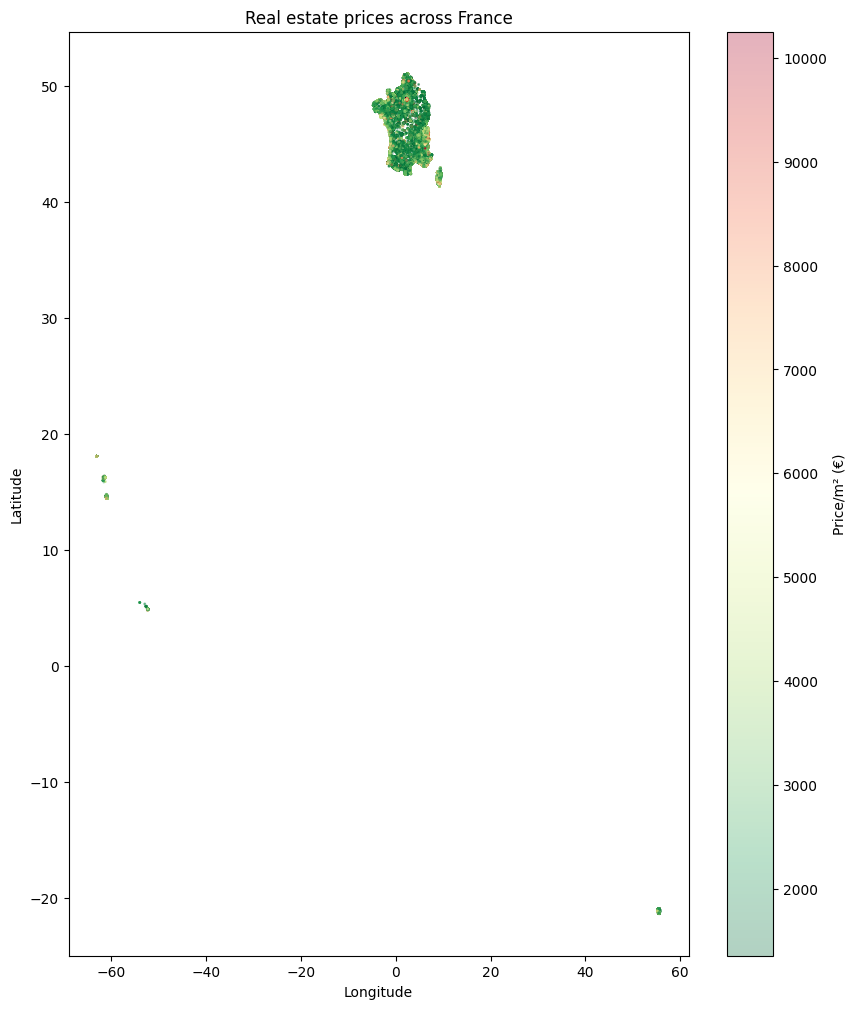

In [9]:
plt.figure(figsize=(10, 12))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["prix_m2"],
    cmap="RdYlGn_r",
    alpha=0.3,
    s=1,
)

plt.colorbar(label="Price/m² (€)")
plt.title("Real estate prices across France")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

- Clear price gradient: Paris and Île-de-France show the highest prices (red)
- Côte d'Azur (south-east) forms a second high-price cluster
- The centre and north-east of France show systematically lower prices (green)
- Geographic location alone explains a significant part of price variance

### Standard of living - Correlation

In [38]:
target_corr = corr["MED_SL"].sort_values(ascending=False)

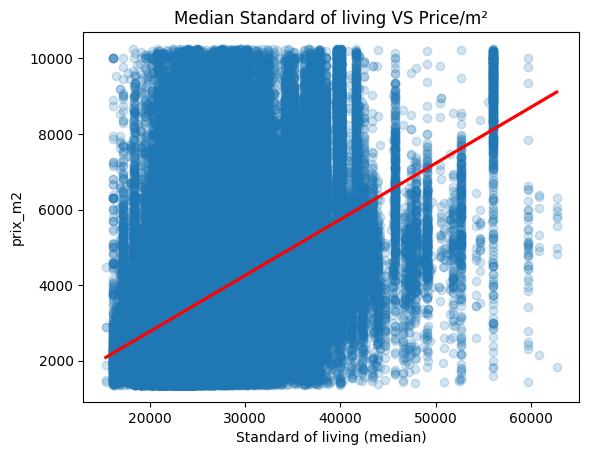

In [11]:
sns.regplot(
    data=analysis_features,
    x="MED_SL",
    y="prix_m2",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"}
)

plt.title("Median Standard of living VS Price/m²")
plt.xlabel("Standard of living (median)")
plt.show()

- Positive linear relationship between median income and price/m²
- High dispersion : income explains part of the price but not all (two communes with the same income can have very different prices)
- The relationship is stronger when aggregated by postal code (less noise)

In [32]:
city_MED_SL = (
    city_analysis_features.groupby("Code postal")
    .agg({
        "prix_m2": "median",
        "MED_SL": "first"
    })
    .reset_index()
)

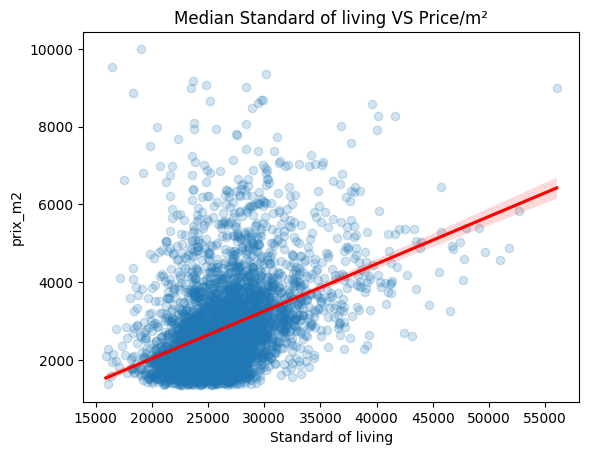

In [33]:
sns.regplot(
    data=city_MED_SL,
    x="MED_SL",
    y="prix_m2",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"}
)


plt.title("Median Standard of living VS Price/m²")
plt.xlabel("Standard of living")
plt.show()

- The relationship becomes much cleaner at commune level
- Confirms that local wealth is a structural driver, not a transaction-level noise
- A few outliers (high price, low income) likely correspond to tourist areas
  (ski resorts, coastal communes) where prices are driven by demand, not local income

### Unemployment rate - Correlation

In [39]:
target_corr = corr["CHOMAGE"].sort_values(ascending=False)

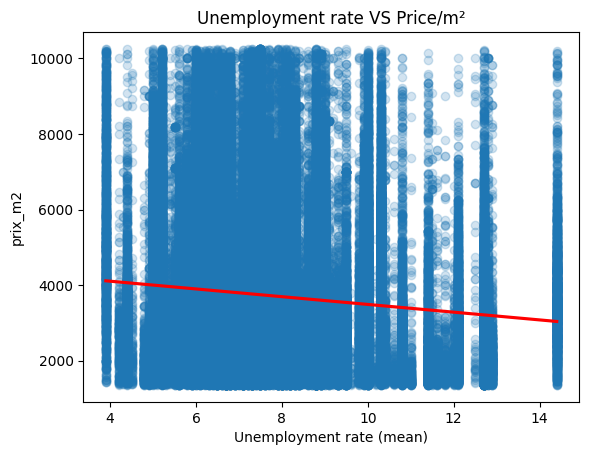

In [15]:
sns.regplot(
    data=analysis_features,
    x="CHOMAGE",
    y="prix_m2",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"}
)

plt.title("Unemployment rate VS Price/m²")
plt.xlabel("Unemployment rate (mean)")
plt.show()

- Negative correlation with prix_m2 - higher unemployment → lower prices
- Weaker signal than income : unemployment is a consequence of economic weakness rather than a direct price driver
- High dispersion : some high-unemployment areas still have high prices
  (tourist zones with seasonal employment)

### Real estate value - Correlation

In [35]:
target_corr = corr["Valeur fonciere"].sort_values(ascending=False)

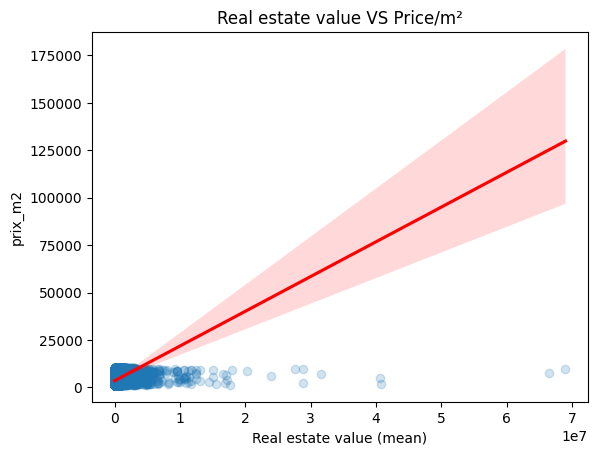

In [17]:
sns.regplot(
    data=analysis_features,
    x="Valeur fonciere",
    y="prix_m2",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"}
)

plt.title("Real estate value VS Price/m²")
plt.xlabel("Real estate value (mean)")
plt.show()

- Strong positive correlation with prix_m2 by construction
  (prix_m2 = Valeur fonciere / Surface) - not informative as a predictor
- Confirms that this variable must be excluded from the RF model
  to avoid data leakage

## Feature importance (Random Forest)

### Real Estate

In [24]:
X, y = prepare_rf_features(df,
                           features=features_RF,
                           target="prix_m2")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R²  : {r2_score(y_test, y_pred):.3f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred):,.0f} €/m²")

  Rows kept   : 335,842 / 379,890
  Rows dropped: 44,048 (NaN)
R²  : 0.523
MAE : 867 €/m²


- R² ~ 0.5–0.6 : the model explains 50-60% of price variance using only socio-economic and geographic features (no property-level data)
- MAE ~ 800–900 €/m² : reasonable error given the scope of the analysis
- Performance would increase significantly by adding property type and city-level features

#### Feature importance visualization

In [34]:
importance_df = (
    pd.DataFrame({"feature": X.columns, "importance": model.feature_importances_})
    .sort_values("importance", ascending=False)
)

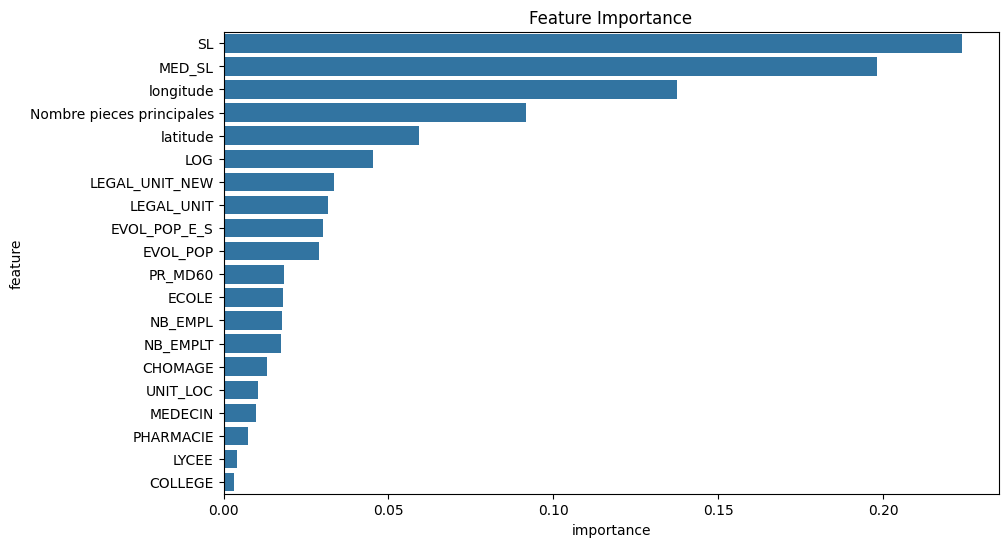

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="importance",
    y="feature"
)

plt.title("Feature Importance")
plt.show()

| Feature              | Importance   | Analysis                                                                                      |
|----------------------|--------------|-----------------------------------------------------------------------------------------------|
| SL                   | 0.22         | (22%) High-wage areas have higher prices                                                      |
| MED_SL               | 0.2          | (20%) Local income is the main socio-economic factor in the real estate market                |
| Latitude + Longitude | 0.14 + 0.06  | (14% + 6%) Differentiate: North/South, Paris, littoral, large metropolitan areas, Côte d'Azur |
| LOG                  | 0.045        | (4.5%) Distinguishes: urban density, size of municipality, real estate tension                |

Real estate prices are mainly explained by:
1. The level of local wealth (income, wages)
2. Geography (latitude/longitude)
3. The type of property (number of rooms = Nombre pieces principales)
4. Territorial dynamism (jobs, businesses)


Infrastructure variables (MEDECIN, ECOLE) have low individual importance but collectively reflect territorial attractiveness

### Territorial

In [28]:
X, y = prepare_rf_features(df,
                           features=features_RF,
                           target="prix_m2")

X = X.drop(columns="Nombre pieces principales").dropna()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R²  : {r2_score(y_test, y_pred):.3f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred):,.0f} €/m²")

  Rows kept   : 335,842 / 379,890
  Rows dropped: 44,048 (NaN)
R²  : 0.493
MAE : 903 €/m²


#### Feature importance visualization

In [36]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_,
})

importance_df = importance_df.sort_values("importance", ascending=False)

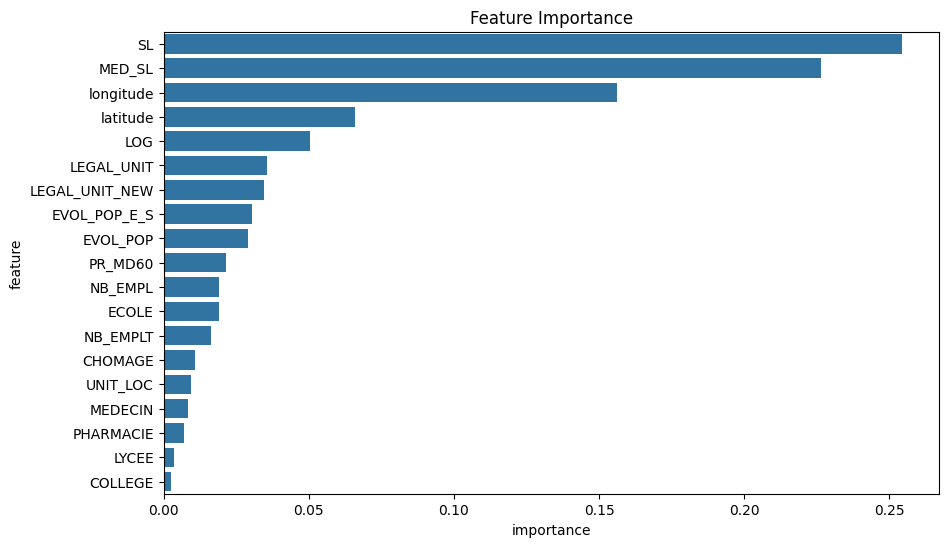

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="importance",
    y="feature"
)

plt.title("Feature Importance")
plt.show()

| Feature              | With type of property | Without     | Comments                                                                                                                       |
|----------------------|-----------------------|-------------|--------------------------------------------------------------------------------------------------------------------------------|
| SL                   | 0.22                  | 0.25        | Without Nombre pieces principales, SL and MED_SL gain importance                                                               |
| MED_SL               | 0.2                   | 0.23        |                                                                                                                                |
| Latitude + Longitude | 0.14 + 0.06           | 0.16 + 0.07 | Geography (latitude/longitude) becomes relatively more important (confirms that location captures what income doesn't explain) |
| LOG                  | 0.045                 | 0.05        | LOG (and NB_EMPLT) gain slightly : urban size matters more when property-level features are removed                            |

Overall ranking is stable : income → geography → urban density